# Restaurant Sales — AI Demand Forecasting
**Infotact Technical Internship | Project 3**

---
| Week | Topic |
|------|-------|
| Week 1 | Data Loading, Diagnose, Clean, EDA |
| Week 2 | Feature Engineering, Train/Test Split |


---
# Section 1 — Import Libraries and Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import warnings
warnings.filterwarnings("ignore")

print("Libraries imported!")

Libraries imported!


In [2]:
df = pd.read_csv("restaurant_sales_messy.csv")

print(f"Rows    : {len(df):,}")
print(f"Columns : {len(df.columns)}")
print(f"Columns : {list(df.columns)}")

Rows    : 106,697
Columns : 11
Columns : ['date', 'outlet', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'is_summer', 'is_monsoon', 'temperature', 'menu_item', 'units_sold']


In [3]:
df.head(10)

,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-11-29,Banashankari,Monday,11.0,FALSE,No,No,FALSE,21.5,masala dosa,72.0
1,08/29/2022,HSR Layout,Monday,8.0,0,FALSE,0,true,24.9,biryani,88.0
2,17-05-2023,NaN,Wednesday,5.0,no,0,1,false,NaN,veg_thali,142.0
3,2023-11-26,Koramangala,Sunday,11.0,1,N,FALSE,0,20.3,Masala Dosa,133.0
4,18-01-2021,Whitefield,Monday,1.0,false,No,No,No,21.0,Vegthali,92.0
5,2023-01-02,MG Road,Monday,1.0,0,no,0,false,20.6,Vegthali,155.0
6,2021-04-13,Hebbal,Tuesday,4.0,N,0,TRUE,no,31.8,chicken_burger,67.0
7,06/03/2022,MG Road,Friday,6.0,No,false,1,FALSE,NaN,ColdCoffee,101.0
8,15-10-2022,Banashankari,Saturday,10.0,NaN,0,0,FALSE,26.0,PANEER TIKKA,91.0
9,2022/01/10,Marathahalli,Monday,1.0,0,No,No,FALSE,24.8,veg_thali,106.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 106697 entries, 0 to 106696
Data columns (total 11 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   date         106697 non-null  object 
 1   outlet       105052 non-null  object 
 2   day_of_week  104584 non-null  object 
 3   month        105117 non-null  float64
 4   is_weekend   103544 non-null  object 
 5   is_holiday   103482 non-null  object 
 6   is_summer    103482 non-null  object 
 7   is_monsoon   103613 non-null  object 
 8   temperature  103514 non-null  float64
 9   menu_item    106697 non-null  object 
 10  units_sold   102400 non-null  float64
dtypes: float64(3), object(8)
memory usage: 9.0+ MB


In [5]:
df.describe()

,month,temperature,units_sold
count,105117.000000,103514.000000,102400.000000
mean,6.525082,24.495568,84.220762
std,3.447520,8.551569,55.404486
min,1.000000,-5.000000,-243.000000
25%,4.000000,21.500000,55.000000
50%,7.000000,23.400000,78.000000
75%,10.000000,26.200000,103.000000
max,12.000000,150.000000,2619.000000


---
# Section 2 — Diagnose: Find All Problems

## 2.1 Missing Values

In [6]:
missing_count = df.isnull().sum()
missing_pct   = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    "Missing Count" : missing_count,
    "Missing %"     : missing_pct
}).sort_values("Missing %", ascending=False)

print(missing_summary)

             Missing Count  Missing %
units_sold            4297       4.03
is_summer             3215       3.01
is_holiday            3215       3.01
temperature           3183       2.98
is_weekend            3153       2.96
is_monsoon            3084       2.89
day_of_week           2113       1.98
outlet                1645       1.54
month                 1580       1.48
date                     0       0.00
menu_item                0       0.00


## 2.2 Inconsistent Boolean Columns

In [7]:
for col in ["is_weekend","is_holiday","is_summer","is_monsoon"]:
    print(f"{col}: {df[col].unique()}")

is_weekend: ['FALSE' '0' 'no' '1' 'false' 'N' 'No' nan 'Y' 'yes' 'TRUE' 'true' 'Yes']
is_holiday: ['No' 'FALSE' '0' 'N' 'no' 'false' 'Y' '1' nan 'TRUE' 'yes' 'Yes' 'true']
is_summer: ['No' '0' '1' 'FALSE' 'TRUE' 'N' 'Yes' 'yes' nan 'no' 'Y' 'true' 'false']
is_monsoon: ['FALSE' 'true' 'false' '0' 'No' 'no' 'TRUE' '1' 'N' 'Y' 'Yes' 'yes' nan]


## 2.3 Messy Outlet Names

In [8]:
print(f"Unique outlets (raw): {df['outlet'].nunique()}")
print(df["outlet"].unique())

Unique outlets (raw): 63
['Banashankari' 'HSR Layout' nan 'Koramangala' 'Whitefield' 'MG Road'
 'Hebbal' 'Marathahalli' 'Electronic City' 'Indiranagar' 'BANASHANKARI'
 'Jayanagar' 'Yelahanka' 'Rajajinagar' 'mg road' 'hsr layout' 'Jayanagar '
 'MARATHAHALLI' 'KORAMANGALA' 'MG_Road' 'yelahanka' 'jayanagar'
 'HSR_Layout' 'RAJAJINAGAR' ' Indiranagar' ' Electronic City' 'HEBBAL'
 ' MG Road' ' Whitefield' 'Koramangala ' 'hebbal' ' Banashankari'
 ' Rajajinagar' 'marathahalli' 'YELAHANKA' 'electronic city'
 ' Koramangala' 'JAYANAGAR' 'HSR LAYOUT' 'Electronic_City' 'Indiranagar '
 'Yelahanka ' 'Electronic City ' 'WHITEFIELD' 'whitefield' 'indiranagar'
 ' Jayanagar' 'Marathahalli ' 'rajajinagar' 'HSR Layout ' ' Marathahalli'
 ' HSR Layout' 'Rajajinagar ' ' Yelahanka' ' Hebbal' 'MG ROAD' 'Hebbal '
 'INDIRANAGAR' 'ELECTRONIC CITY' 'MG Road ' 'Whitefield ' 'Banashankari '
 'banashankari' 'koramangala']


## 2.4 Messy Menu Item Names

In [9]:
print(f"Unique menu items (raw): {df['menu_item'].nunique()}")
print(df["menu_item"].unique())

Unique menu items (raw): 56
['masala dosa' 'biryani' 'veg_thali' 'Masala Dosa' 'Vegthali'
 'chicken_burger' 'ColdCoffee' 'PANEER TIKKA' 'veg  thali'
 'Chicken Burger' 'gulab_jamun' 'PaneerTikka' 'Butter Chiken' 'Biryani'
 'Veg. Thali' 'Briyani' 'MasalaDosa' 'Chcken Burger' 'Veg Thali'
 'Biriyani' 'biryani ' 'Cold Coffee' 'chicken burger' 'VEG THALI'
 'butter chicken' 'MASALA DOSA' 'masla dosa' 'BUTTER CHICKEN'
 'Masala  Dosa' 'Gulab Jaamun' 'butter_chicken' 'paneer_tikka'
 'COLD COFFEE' 'Butter Chicken' 'Cold Coffe' 'gulab jamun' 'veg thali'
 'Gulaab Jamun' 'Chiken Burger' 'Paneer Tikka' 'cold_coffee' 'cold cofee'
 'Butter  Chicken' 'Panner Tikka' 'Chicken  Burger' 'GULAB JAMUN'
 'BIRYANI' 'Gulab Jamun' 'Paneer Tika' 'Bryani' 'cold coffee'
 'paneer tikka' 'Gulb Jamun' 'Bttr Chicken' 'CHICKEN BURGER' 'masala_dosa']


## 2.5 Mixed Date Formats

In [10]:
print(df["date"].unique()[:20])

['2021-11-29' '08/29/2022' '17-05-2023' '2023-11-26' '18-01-2021'
 '2023-01-02' '2021-04-13' '06/03/2022' '15-10-2022' '2022/01/10'
 '2022-08-13' '2021-09-04' '20/09/2022' '01/19/2023' '02/05/2021'
 '18/06/2022' '2021-05-20' '2023-12-03' '2023/07/25' '19-05-2021']


## 2.6 Temperature Outliers

In [11]:
print(f"Min temperature : {df['temperature'].min()}")
print(f"Max temperature : {df['temperature'].max()}")
print(f"Outliers found  : {((df['temperature']<15) | (df['temperature']>40)).sum()}")

Min temperature : -5.0
Max temperature : 150.0
Outliers found  : 825


## 2.7 Negative Units Sold

In [12]:
print(f"Negative units_sold: {(df['units_sold'] < 0).sum()}")

Negative units_sold: 300


---
# Section 3 — Data Cleaning

## 3.1 Fix Date Column (5 Mixed Formats to 1 Standard Format)

In [13]:
# Replace all "/" with "-" so all dates use same separator
df["date"] = df["date"].str.replace("/", "-")

# Try each date format one by one
df["date_parsed"] = pd.to_datetime(df["date"], format="%d-%m-%Y", errors="coerce")

mask = df["date_parsed"].isna()
df.loc[mask, "date_parsed"] = pd.to_datetime(df.loc[mask, "date"], format="%m-%d-%Y", errors="coerce")

mask = df["date_parsed"].isna()
df.loc[mask, "date_parsed"] = pd.to_datetime(df.loc[mask, "date"], format="%Y-%m-%d", errors="coerce")

df["date"] = df["date_parsed"]
del df["date_parsed"]

df = df.sort_values(by="date", ascending=True).reset_index(drop=True)

print(f"Dates still missing : {df['date'].isnull().sum()}")
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")

Dates still missing : 0
Date range: 2021-01-01 to 2023-12-31


## 3.2 Fix Boolean Columns (Yes/No/TRUE/FALSE to 1/0)

In [14]:
cols = ["is_weekend", "is_holiday", "is_summer", "is_monsoon"]

df[cols] = df[cols].replace({
    "Yes":1, "yes":1, "Y":1, "y":1, "TRUE":1, "True":1, "true":1,
    "No" :0, "no" :0, "N":0, "n":0, "FALSE":0, "False":0, "false":0
})

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce")

for col in cols:
    print(f"  {col}: {sorted(df[col].dropna().unique())}")

  is_weekend: [np.float64(0.0), np.float64(1.0)]
  is_holiday: [np.float64(0.0), np.float64(1.0)]
  is_summer: [np.float64(0.0), np.float64(1.0)]
  is_monsoon: [np.float64(0.0), np.float64(1.0)]


## 3.3 Fix Outlet Names (63 Variants to 12 Clean Names)

In [15]:
df["outlet"] = df["outlet"].str.strip().str.lower().str.replace("_", " ")

df["outlet"] = df["outlet"].replace({
    "mg road"         : "MG Road",
    "hsr layout"      : "HSR Layout",
    "yelahanka"       : "Yelahanka",
    "jayanagar"       : "Jayanagar",
    "hebbal"          : "Hebbal",
    "marathahalli"    : "Marathahalli",
    "electronic city" : "Electronic City",
    "whitefield"      : "Whitefield",
    "indiranagar"     : "Indiranagar",
    "rajajinagar"     : "Rajajinagar",
    "banashankari"    : "Banashankari",
    "koramangala"     : "Koramangala"
})

df["outlet"] = df["outlet"].fillna(df["outlet"].mode()[0])

print(f"Unique outlets after fix: {df['outlet'].nunique()}")
print(df["outlet"].unique())

Unique outlets after fix: 12
['Koramangala' 'MG Road' 'Banashankari' 'Marathahalli' 'Jayanagar'
 'HSR Layout' 'Yelahanka' 'Hebbal' 'Rajajinagar' 'Whitefield'
 'Electronic City' 'Indiranagar']


## 3.4 Fix Menu Item Names (56 Variants to 8 Clean Items)

In [16]:
df["menu_item"] = df["menu_item"].str.strip().str.lower().str.replace("_", " ")

df["menu_item"] = df["menu_item"].replace({
    "masala dosa":"Masala Dosa", "masaladosa":"Masala Dosa",
    "masla dosa" :"Masala Dosa", "masala  dosa":"Masala Dosa",
    "biryani"    :"Biryani",     "biriyani":"Biryani",
    "briyani"    :"Biryani",     "bryani"  :"Biryani",
    "veg thali"  :"Veg Thali",   "veg. thali":"Veg Thali",
    "vegthali"   :"Veg Thali",   "veg  thali":"Veg Thali",
    "butter chicken":"Butter Chicken", "butter chiken":"Butter Chicken",
    "butter  chicken":"Butter Chicken","bttr chicken":"Butter Chicken",
    "chicken burger":"Chicken Burger", "chcken burger":"Chicken Burger",
    "chiken burger" :"Chicken Burger", "chicken  burger":"Chicken Burger",
    "paneer tikka":"Paneer Tikka", "paneertikka":"Paneer Tikka",
    "paneer tika" :"Paneer Tikka", "panner tikka":"Paneer Tikka",
    "cold coffee":"Cold Coffee",  "coldcoffee":"Cold Coffee",
    "cold coffe" :"Cold Coffee",  "cold cofee" :"Cold Coffee",
    "gulab jamun" :"Gulab Jamun", "gulab jaamun":"Gulab Jamun",
    "gulaab jamun":"Gulab Jamun", "gulb jamun"  :"Gulab Jamun",
})

print(f"Unique menu items after fix: {df['menu_item'].nunique()}")
print(df["menu_item"].unique())

Unique menu items after fix: 8
['Gulab Jamun' 'Cold Coffee' 'Butter Chicken' 'Biryani' 'Chicken Burger'
 'Masala Dosa' 'Veg Thali' 'Paneer Tikka']


## 3.5 Fill Remaining Missing Values

In [17]:
df["month"]       = df["date"].dt.month
df["day_of_week"] = df["date"].dt.day_name()

# Re-calculate is_weekend from the actual date
df["is_weekend"] = df["date"].dt.dayofweek.isin([5, 6]).astype(int)

# Fill is_summer: April, May, June
df["is_summer"] = df["is_summer"].fillna(df["month"].isin([4, 5, 6]).astype(int))

# Fill is_monsoon: July, August, September
df["is_monsoon"] = df["is_monsoon"].fillna(df["month"].isin([7, 8, 9]).astype(int))

# Fill is_holiday with 0
df["is_holiday"] = df["is_holiday"].fillna(0)

# Fill temperature with monthly median
df["temperature"] = df.groupby("month")["temperature"].transform(
    lambda x: x.fillna(x.median())
)

# Drop rows with missing units_sold (target column)
df = df.dropna(subset=["units_sold"]).reset_index(drop=True)

print("Missing values after cleaning:")
print(df.isnull().sum())

Missing values after cleaning:
date           0
outlet         0
day_of_week    0
month          0
is_weekend     0
is_holiday     0
is_summer      0
is_monsoon     0
temperature    0
menu_item      0
units_sold     0
dtype: int64


## 3.6 Fix Outliers (Temperature and Units Sold)

In [18]:
# IQR method: clip values that are too extreme
for col in ["temperature", "units_sold"]:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    df[col] = df[col].clip(Q1 - 1.5 * IQR, Q3 + 1.5 * IQR)
    print(f"{col} -> min: {df[col].min():.1f}, max: {df[col].max():.1f}")

df = df[df["units_sold"] >= 0].reset_index(drop=True)
print(f"Final clean shape: {df.shape}")

temperature -> min: 14.5, max: 33.2
units_sold -> min: -17.0, max: 175.0
Final clean shape: (102100, 11)


In [19]:
df.to_csv("restaurant_sales_clean.csv", index=False)
print("Clean data saved as restaurant_sales_clean.csv")
df.head()

Clean data saved as restaurant_sales_clean.csv


,date,outlet,day_of_week,month,is_weekend,is_holiday,is_summer,is_monsoon,temperature,menu_item,units_sold
0,2021-01-01,Koramangala,Friday,1,0,0.0,0.0,0.0,22.1,Gulab Jamun,34.0
1,2021-01-01,MG Road,Friday,1,0,0.0,0.0,0.0,20.2,Cold Coffee,64.0
2,2021-01-01,MG Road,Friday,1,0,0.0,0.0,0.0,20.8,Butter Chicken,118.0
3,2021-01-01,Banashankari,Friday,1,0,0.0,0.0,0.0,20.9,Biryani,87.0
4,2021-01-01,Marathahalli,Friday,1,0,0.0,0.0,0.0,20.4,Chicken Burger,56.0


---
# Section 4 — Exploratory Data Analysis (EDA)

## 4.1 Daily Sales Trend + 30-Day Rolling Average

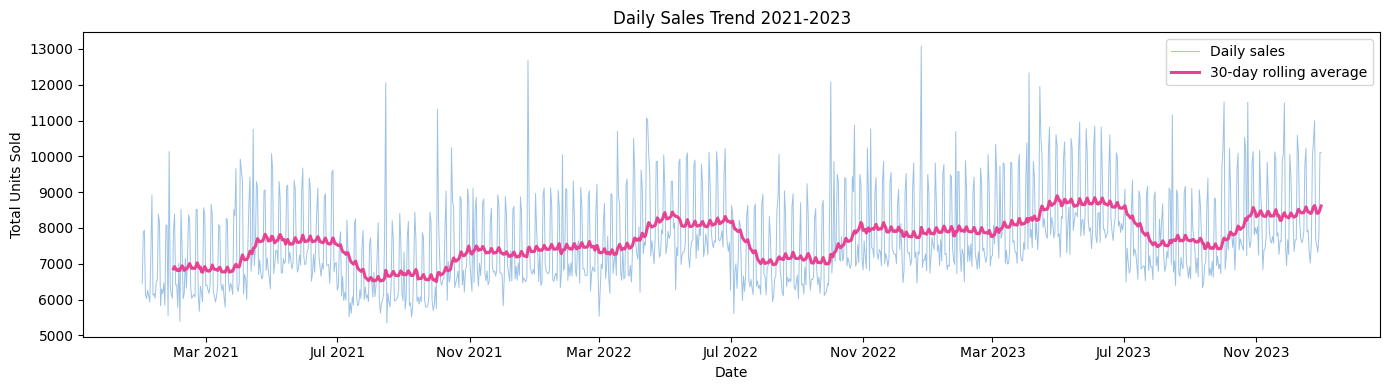

In [20]:
daily_sales = df.groupby("date")["units_sold"].sum().reset_index().sort_values("date")
daily_sales["rolling_30"] = daily_sales["units_sold"].rolling(30).mean()

fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(daily_sales["date"], daily_sales["units_sold"],
        color="#5B9BD5", lw=0.7, alpha=0.6, label="Daily sales")
ax.plot(daily_sales["date"], daily_sales["rolling_30"],
        color="#E84393", lw=2.2, label="30-day rolling average")

ax.set(xlabel="Date", ylabel="Total Units Sold", title="Daily Sales Trend 2021-2023")
ax.legend()
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.tight_layout()
plt.show()

## 4.2 Day / Month / Outlet / Item Charts

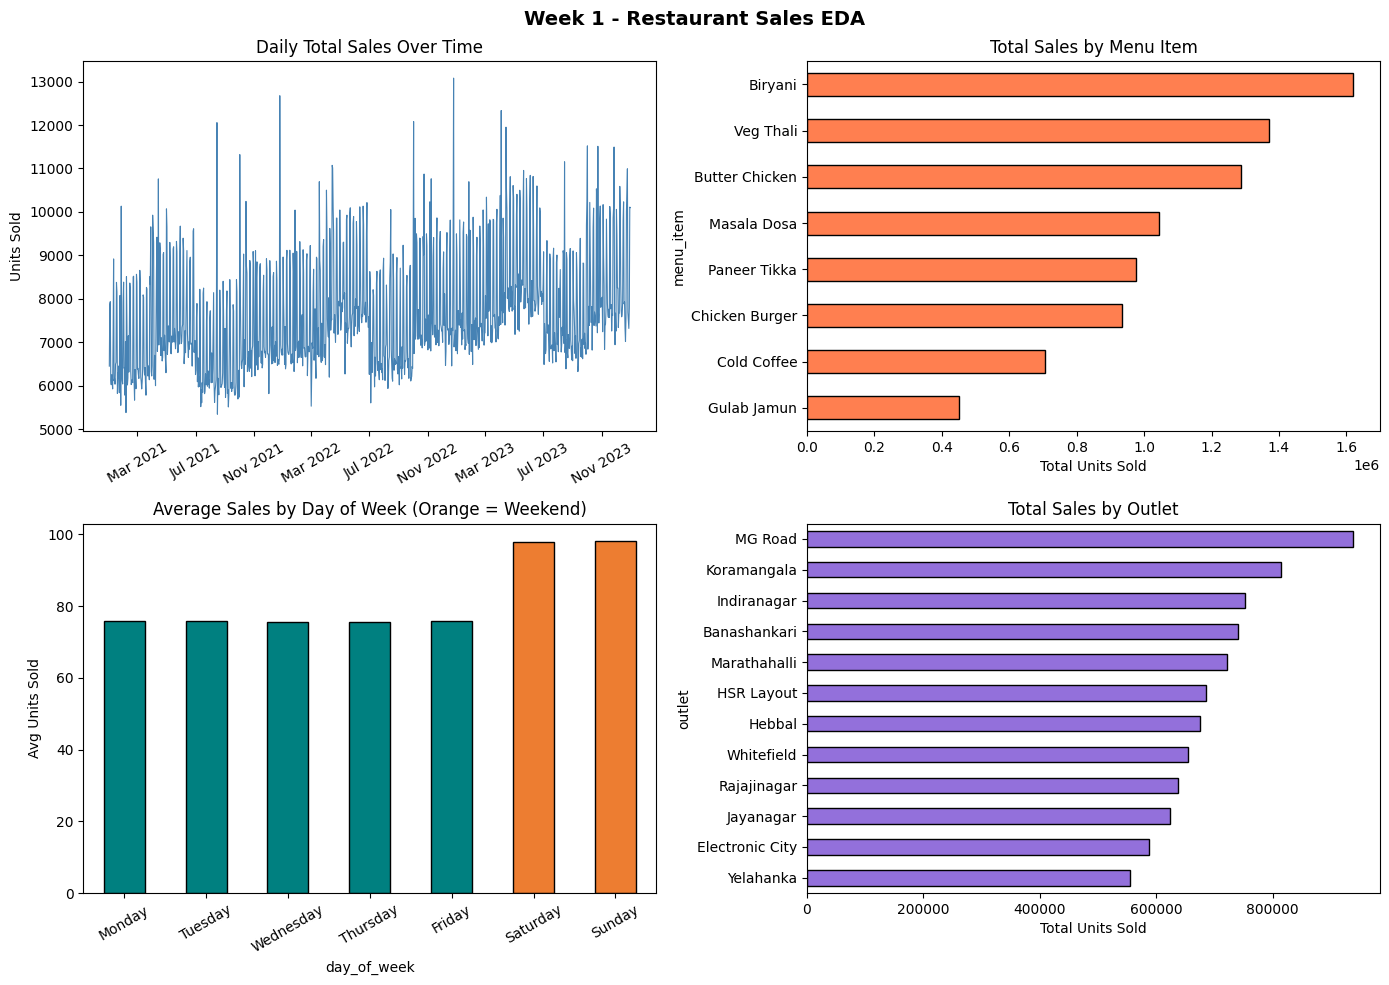

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Week 1 - Restaurant Sales EDA", fontsize=14, fontweight="bold")

# Chart 1: Daily trend
ax = axes[0, 0]
ax.plot(daily_sales["date"], daily_sales["units_sold"],
        color="steelblue", linewidth=0.8)
ax.set_title("Daily Total Sales Over Time")
ax.set_ylabel("Units Sold")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=4))
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Chart 2: Best selling item
ax = axes[0, 1]
item_totals = df.groupby("menu_item")["units_sold"].sum().sort_values()
item_totals.plot(kind="barh", ax=ax, color="coral", edgecolor="black")
ax.set_title("Total Sales by Menu Item")
ax.set_xlabel("Total Units Sold")

# Chart 3: Best day of week
ax = axes[1, 0]
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
day_avg = df.groupby("day_of_week")["units_sold"].mean().reindex(day_order)
colors_day = ["#ED7D31" if d in ["Saturday","Sunday"] else "teal" for d in day_order]
day_avg.plot(kind="bar", ax=ax, color=colors_day, edgecolor="black")
ax.set_title("Average Sales by Day of Week (Orange = Weekend)")
ax.set_ylabel("Avg Units Sold")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=30)

# Chart 4: Best outlet
ax = axes[1, 1]
outlet_totals = df.groupby("outlet")["units_sold"].sum().sort_values()
outlet_totals.plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="black")
ax.set_title("Total Sales by Outlet")
ax.set_xlabel("Total Units Sold")

plt.tight_layout()
plt.show()

## 4.3 Flag-Wise Sales (Weekend / Holiday / Summer / Monsoon)

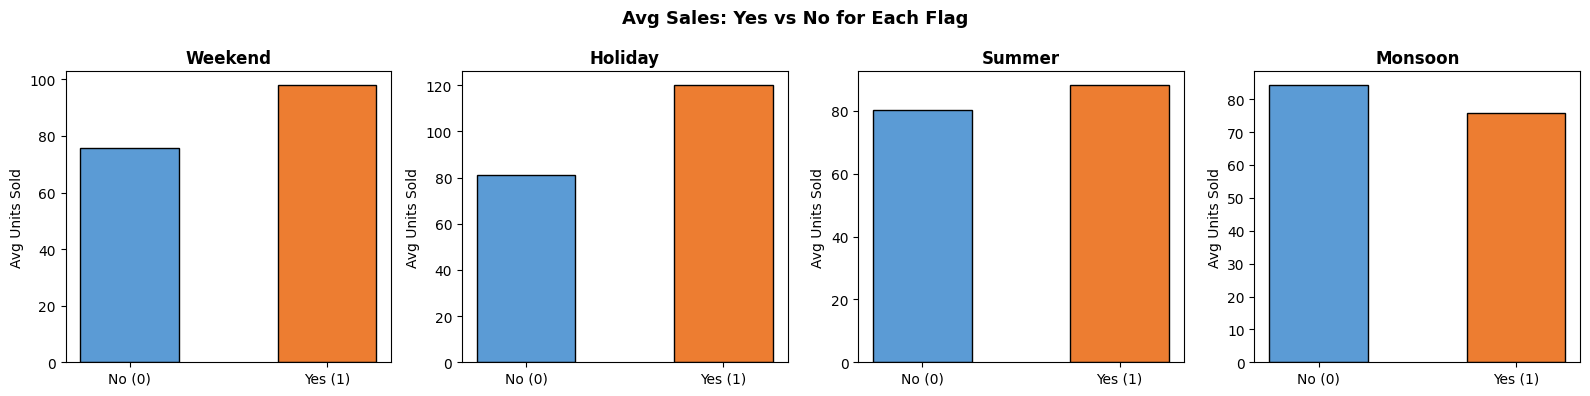

In [22]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle("Avg Sales: Yes vs No for Each Flag", fontsize=13, fontweight="bold")

flags  = ["is_weekend", "is_holiday", "is_summer", "is_monsoon"]
titles = ["Weekend",    "Holiday",    "Summer",    "Monsoon"]

for ax, col, title in zip(axes, flags, titles):
    avg = df.groupby(col)["units_sold"].mean()
    ax.bar(["No (0)", "Yes (1)"], [avg.get(0, 0), avg.get(1, 0)],
           color=["#5B9BD5", "#ED7D31"], edgecolor="black", width=0.5)
    ax.set_title(title, fontweight="bold")
    ax.set_ylabel("Avg Units Sold")

plt.tight_layout()
plt.show()

## 4.4 Outlet x Menu Item Heatmap

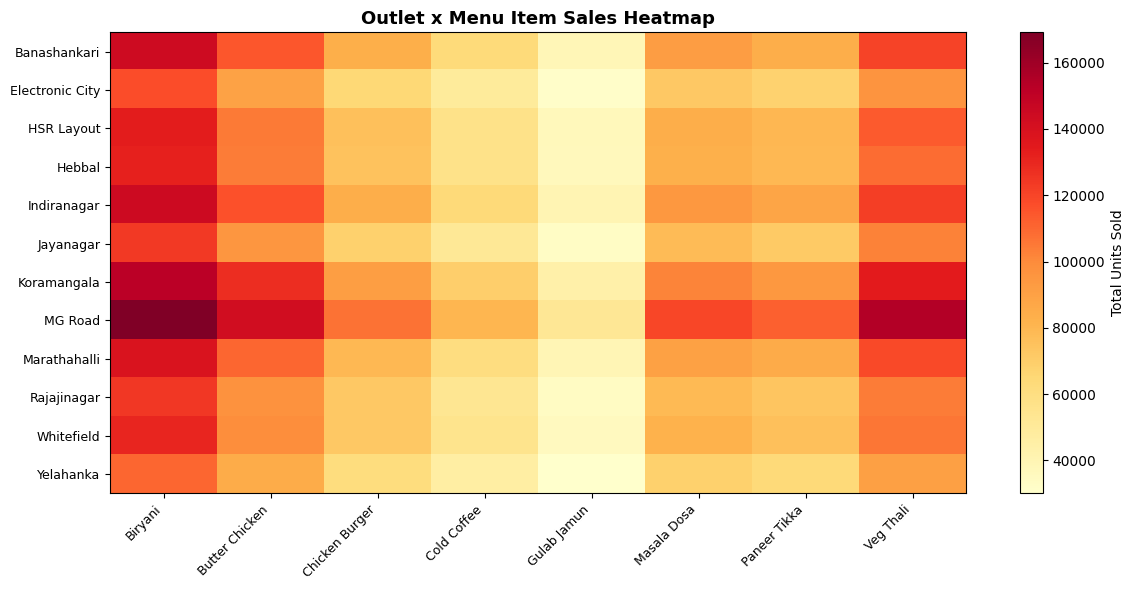

In [23]:
pivot = df.pivot_table(values="units_sold", index="outlet",
                       columns="menu_item", aggfunc="sum")

fig, ax = plt.subplots(figsize=(12, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label="Total Units Sold")
ax.set_title("Outlet x Menu Item Sales Heatmap", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 4.5 Temperature vs Units Sold

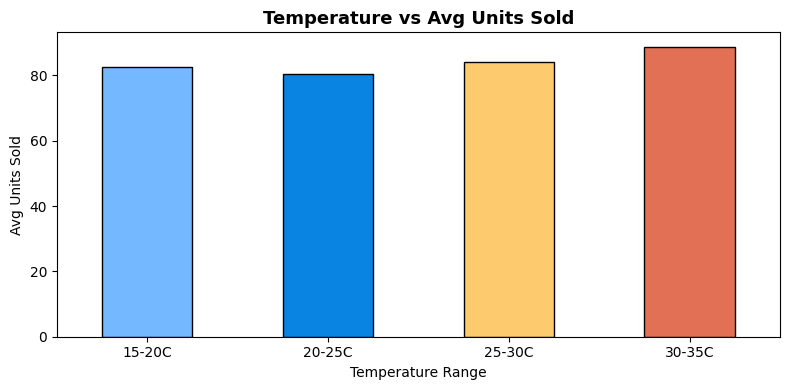

In [24]:
temp_df = df.dropna(subset=["temperature"]).copy()
temp_df["temp_range"] = pd.cut(temp_df["temperature"],
                               bins=[15,20,25,30,35,40],
                               labels=["15-20C","20-25C","25-30C","30-35C","35-40C"])
temp_avg = temp_df.groupby("temp_range", observed=True)["units_sold"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
temp_avg.plot(kind="bar", ax=ax,
              color=["#74b9ff","#0984e3","#fdcb6e","#e17055","#d63031"],
              edgecolor="black")
ax.set_title("Temperature vs Avg Units Sold", fontsize=13, fontweight="bold")
ax.set_ylabel("Avg Units Sold")
ax.set_xlabel("Temperature Range")
plt.setp(ax.xaxis.get_majorticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 4.6 EDA Key Findings Summary

In [25]:
day_order = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]

best_day    = df.groupby("day_of_week")["units_sold"].mean().reindex(day_order).idxmax()
best_item   = df.groupby("menu_item")["units_sold"].sum().idxmax()
best_outlet = df.groupby("outlet")["units_sold"].sum().idxmax()
wknd_avg    = df[df["is_weekend"]==1]["units_sold"].mean()
wkdy_avg    = df[df["is_weekend"]==0]["units_sold"].mean()

print("KEY EDA FINDINGS")
print("-" * 40)
print(f"Best selling day    : {best_day}")
print(f"Best selling item   : {best_item}")
print(f"Top outlet          : {best_outlet}")
print(f"Weekend avg sales   : {wknd_avg:.1f} units")
print(f"Weekday avg sales   : {wkdy_avg:.1f} units")
print(f"Weekend boost       : +{(wknd_avg-wkdy_avg)/wkdy_avg*100:.1f}%")

KEY EDA FINDINGS
----------------------------------------
Best selling day    : Sunday
Best selling item   : Biryani
Top outlet          : MG Road
Weekend avg sales   : 98.0 units
Weekday avg sales   : 75.7 units
Weekend boost       : +29.3%


---
# Section 5 — Feature Engineering (Week 2)

## 5.1 Aggregate to Daily Level
One row per day (sum of all outlets and items) — needed for time-series forecasting

In [26]:
daily = df.groupby("date").agg(
    total_units = ("units_sold",  "sum"),
    avg_temp    = ("temperature", "mean"),
    is_holiday  = ("is_holiday",  "max"),
    is_summer   = ("is_summer",   "max"),
    is_monsoon  = ("is_monsoon",  "max"),
).reset_index().sort_values("date").reset_index(drop=True)

# Add any missing dates with 0 sales (no gaps allowed in time-series)
all_dates = pd.date_range(daily["date"].min(), daily["date"].max(), freq="D")
daily = daily.set_index("date").reindex(all_dates).rename_axis("date").reset_index()
daily["total_units"] = daily["total_units"].fillna(0)
daily["is_holiday"]  = daily["is_holiday"].fillna(0)
daily["avg_temp"]    = daily["avg_temp"].interpolate()

print(f"Daily rows: {len(daily)}")
daily.head()

Daily rows: 1095


,date,total_units,avg_temp,is_holiday,is_summer,is_monsoon
0,2021-01-01,6453.0,21.150526,0.0,0.0,0.0
1,2021-01-02,7878.0,21.488021,0.0,0.0,0.0
2,2021-01-03,7936.0,21.560526,0.0,0.0,0.0
3,2021-01-04,6141.0,21.969149,0.0,1.0,0.0
4,2021-01-05,6026.0,21.498276,0.0,1.0,0.0


## 5.2 Calendar Features
Extract useful numbers from the date — month, day of week, quarter etc.

In [27]:
daily["day_of_week"]  = daily["date"].dt.dayofweek   # 0=Monday, 6=Sunday
daily["day_of_month"] = daily["date"].dt.day
daily["month"]        = daily["date"].dt.month
daily["quarter"]      = daily["date"].dt.quarter
daily["year"]         = daily["date"].dt.year
daily["is_weekend"]   = daily["date"].dt.dayofweek.isin([5, 6]).astype(int)
daily["is_summer"]    = daily["is_summer"].fillna(daily["month"].isin([4,5,6]).astype(int))
daily["is_monsoon"]   = daily["is_monsoon"].fillna(daily["month"].isin([7,8,9]).astype(int))

# People eat out more at start and end of month (salary day effect)
daily["is_month_start"] = (daily["date"].dt.day <= 5).astype(int)
daily["is_month_end"]   = (daily["date"].dt.day >= 25).astype(int)

print("Calendar features added!")
print(list(daily.columns))

Calendar features added!
['date', 'total_units', 'avg_temp', 'is_holiday', 'is_summer', 'is_monsoon', 'day_of_week', 'day_of_month', 'month', 'quarter', 'year', 'is_weekend', 'is_month_start', 'is_month_end']


## 5.3 Lag Features
"What were the sales N days ago?" — helps the model learn from past patterns

lag_7 is the strongest predictor because weekly patterns repeat!

In [28]:
daily["lag_1"]  = daily["total_units"].shift(1)   # yesterday
daily["lag_7"]  = daily["total_units"].shift(7)   # same day last week
daily["lag_14"] = daily["total_units"].shift(14)  # 2 weeks ago
daily["lag_28"] = daily["total_units"].shift(28)  # 4 weeks ago

print("Lag features added: lag_1, lag_7, lag_14, lag_28")

Lag features added: lag_1, lag_7, lag_14, lag_28


## 5.4 Rolling Window Features
"What was the average sales over the last N days?" — smooths out noise

shift(1) is important! It prevents the model from cheating by seeing today sales.

In [29]:
sales_shifted = daily["total_units"].shift(1)  # not including today

daily["rolling_mean_7"]  = sales_shifted.rolling(7).mean()   # 7-day average
daily["rolling_max_7"]   = sales_shifted.rolling(7).max()
daily["rolling_min_7"]   = sales_shifted.rolling(7).min()
daily["rolling_mean_14"] = sales_shifted.rolling(14).mean()  # 14-day average
daily["rolling_mean_28"] = sales_shifted.rolling(28).mean()  # 28-day average

print("Rolling features added: 7-day, 14-day, 28-day")

Rolling features added: 7-day, 14-day, 28-day


In [30]:
daily["trend"] = (daily["date"] - daily["date"].min()).dt.days
print("Trend feature added!")

Trend feature added!


## 5.6 Remove Rows with Missing Values
First 28 rows will have empty lag/rolling values — drop them

In [31]:
before = len(daily)
daily  = daily.dropna().reset_index(drop=True)
print(f"Removed {before - len(daily)} rows")
print(f"Final dataset: {daily.shape}")
daily.head()

Removed 28 rows
Final dataset: (1067, 24)


,date,total_units,avg_temp,is_holiday,is_summer,is_monsoon,day_of_week,day_of_month,month,quarter,...,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_max_7,rolling_min_7,rolling_mean_14,rolling_mean_28,trend
0,2021-01-29,6043.0,21.642778,0.0,0.0,0.0,4,29,1,1,...,6130.0,5841.0,6540.0,6453.0,7168.142857,10133.0,5552.0,6999.928571,6845.821429,28
1,2021-01-30,7930.0,20.873626,0.0,0.0,0.0,5,30,1,1,...,6043.0,8078.0,8380.0,7878.0,7197.000000,10133.0,5552.0,6964.428571,6831.178571,29
2,2021-01-31,8385.0,21.518085,0.0,0.0,0.0,6,31,1,1,...,7930.0,8077.0,8160.0,7936.0,7175.857143,10133.0,5552.0,6932.285714,6833.035714,30
3,2021-02-01,6403.0,23.004348,0.0,0.0,0.0,0,1,2,1,...,8385.0,5552.0,5823.0,6141.0,7219.857143,10133.0,5552.0,6948.357143,6849.071429,31
4,2021-02-02,6415.0,22.748936,0.0,0.0,0.0,1,2,2,1,...,6403.0,10133.0,6291.0,6026.0,7341.428571,10133.0,6043.0,6989.785714,6858.428571,32


## 5.7 Train / Test Split (Time-Based, No Data Leakage)
NEVER use random split for time-series! Always use earlier dates for training.

In [32]:
split_idx = int(len(daily) * 0.80)  # 80% train, 20% test

train = daily.iloc[:split_idx].copy()
test  = daily.iloc[split_idx:].copy()

print(f"Train: {train['date'].min().date()} to {train['date'].max().date()} ({len(train)} days)")
print(f"Test : {test['date'].min().date()} to {test['date'].max().date()} ({len(test)} days)")

Train: 2021-01-29 to 2023-05-31 (853 days)
Test : 2023-06-01 to 2023-12-31 (214 days)
